# Notebook 03: Behavioral PD Scorecard — Logistic Regression

## Prior Role Connection
This mirrors the behavioral scorecard RAG framework from institutional
monitoring reports. The same methodology — WoE binning, IV-based feature
selection, coefficient sign enforcement, and points-based scoring — is used
for quarterly portfolio monitoring scorecards.

## Behavioral PD Scorecard — Logistic Regression

This is a behavioral scorecard for portfolio monitoring. These are loans
already on LendingClub's books.

**Why grade is included:** Grade is a known, observed attribute for existing
loans. It captures LendingClub's comprehensive risk assessment at origination
and is the single strongest predictor of default.

**Why int_rate and sub_grade are excluded:** int_rate is mechanically
determined by grade (near-perfect correlation). sub_grade is a finer partition
of grade creating the same collinearity. Including any of these alongside
grade would destabilize coefficient estimates.

**Why macro features are excluded:** In a logistic regression with time-based
train/test split, macro features confound with LendingClub's growth trajectory.
UNRATE falls steadily 2010→2015 while LC's volume and borrower mix change.
This produces inverted coefficient signs (higher unemployment appears to
*decrease* default — which is economically nonsensical). Macro features are
properly handled in the ML PD models (Notebook 04) and stress testing
(Notebooks 08-09) where non-linear models can disentangle these effects.

## Objective
1. Select final features via IV threshold + pairwise correlation filter
2. Fit L2-regularized logistic regression with coefficient sign enforcement
3. Convert to points-based scorecard (Base=600, PDO=20)
4. Validate: AUC ≥ 0.75, Gini ≥ 50%, KS ≥ 35%
5. Build credit policy analysis and grade mapping

## Step 1: Setup — Imports and Configuration

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve

# Project imports
sys.path.insert(0, str(Path('..').resolve()))
from config import (
    DATA_PROCESSED_PATH, DATA_RESULTS_PATH, DATA_MODELS_PATH,
    TARGET_COL, RANDOM_STATE, SCORECARD_BASE, SCORECARD_PDO,
    FRED_SERIES,
)
from src.scorecard import Scorecard

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Scorecard parameters: Base={SCORECARD_BASE}, PDO={SCORECARD_PDO}")
print("Setup complete.")

Scorecard parameters: Base=600, PDO=20
Setup complete.


## Step 2: Load WoE-Transformed Data and IV Summary

The WoE-transformed datasets were created in Notebook 02. Each feature column
contains WoE values (continuous float64). The binner object contains the
original bin edges and WoE mappings needed for scorecard point calculation.

In [2]:
# Load WoE-transformed datasets
train_woe = pd.read_parquet(DATA_PROCESSED_PATH / "train_woe.parquet")
val_woe   = pd.read_parquet(DATA_PROCESSED_PATH / "val_woe.parquet")
test_woe  = pd.read_parquet(DATA_PROCESSED_PATH / "test_woe.parquet")

# Load IV summary
iv_df = pd.read_csv(DATA_PROCESSED_PATH / "iv_summary.csv")

# Load fitted binner (for scorecard table generation)
with open(DATA_PROCESSED_PATH / "woe_binning_results.pkl", "rb") as f:
    binner = pickle.load(f)

# Targets
y_train = train_woe[TARGET_COL]
y_val   = val_woe[TARGET_COL]
y_test  = test_woe[TARGET_COL]

print(f"Train: {train_woe.shape[0]:,} rows × {train_woe.shape[1]} cols  |  "
      f"Default rate: {y_train.mean():.4f}")
print(f"Val:   {val_woe.shape[0]:,} rows × {val_woe.shape[1]} cols  |  "
      f"Default rate: {y_val.mean():.4f}")
print(f"Test:  {test_woe.shape[0]:,} rows × {test_woe.shape[1]} cols  |  "
      f"Default rate: {y_test.mean():.4f}")
print(f"\nIV summary: {len(iv_df)} features evaluated in Notebook 02")

Train: 826,606 rows × 47 cols  |  Default rate: 0.1843
Val:   293,105 rows × 47 cols  |  Default rate: 0.2329
Test:  225,639 rows × 47 cols  |  Default rate: 0.2129

IV summary: 105 features evaluated in Notebook 02


## Step 3: Feature Selection

**Selection criteria:**
1. IV ≥ 0.05 for WoE features (stricter than NB02's IV ≥ 0.02 — we want the
   most discriminating features for a parsimonious scorecard)
2. Binary flags: IV ≥ 0.02 (lower threshold, but must still contribute)
3. EXCLUDE: int_rate, sub_grade (collinear with grade)
4. EXCLUDE: all 6 FRED macro features (confound in linear model)
5. Pairwise |correlation| < 0.70 — drop lower-IV feature in correlated pairs
6. Target: 10–15 final features

In [3]:
# ── Step 3a: IV threshold filter ──
# WoE features: IV >= 0.05
# Binary flags: IV >= 0.02
iv_candidates = iv_df[iv_df["iv"] >= 0.05].copy()

# Also check for binary flags with IV >= 0.02 but < 0.05
binary_flags = iv_df[
    (iv_df["iv"] >= 0.02) & (iv_df["iv"] < 0.05) &
    (iv_df["feature"].str.contains("flag|missing", case=False))
].copy()

print("=" * 80)
print("STEP 3a: IV THRESHOLD FILTER")
print("=" * 80)
print(f"  WoE features with IV >= 0.05: {len(iv_candidates)}")
print(f"  Binary flags with IV >= 0.02: {len(binary_flags)}")

# Combine
candidates = pd.concat([iv_candidates, binary_flags]).drop_duplicates(subset="feature")
candidates = candidates.sort_values("iv", ascending=False).reset_index(drop=True)

print(f"  Combined candidates: {len(candidates)}")
print()
for _, row in candidates.iterrows():
    flag = " [binary flag]" if row["feature"] in binary_flags["feature"].values else ""
    print(f"    {row['feature']:<40s} IV={row['iv']:.4f}  [{row['selection_status']}]{flag}")

STEP 3a: IV THRESHOLD FILTER
  WoE features with IV >= 0.05: 33
  Binary flags with IV >= 0.02: 1
  Combined candidates: 34

    grade                                    IV=0.9420  [strong]
    term                                     IV=0.4806  [strong]
    loan_to_income                           IV=0.2543  [medium]
    fico_range_low                           IV=0.2437  [medium]
    fico_range_high                          IV=0.2437  [medium]
    fico_avg                                 IV=0.2437  [medium]
    installment_to_income                    IV=0.1698  [medium]
    acc_open_past_24mths                     IV=0.1622  [medium]
    dti                                      IV=0.1517  [medium]
    num_tl_op_past_12m                       IV=0.1162  [medium]
    bc_open_to_buy                           IV=0.1121  [medium]
    verification_status                      IV=0.1026  [medium]
    avg_cur_bal                              IV=0.0831  [weak]
    total_bc_limit              

In [4]:
# ── Step 3b: Exclusions ──
print("\n" + "=" * 80)
print("STEP 3b: MANDATORY EXCLUSIONS")
print("=" * 80)

# Features to exclude
MACRO_FEATURES = set(FRED_SERIES)  # UNRATE, CSUSHPINSA, A191RL1Q225SBEA, CPIAUCSL, DFF, UMCSENT
COLLINEAR_WITH_GRADE = {"int_rate", "sub_grade"}

excluded = []
for feat in candidates["feature"]:
    if feat in MACRO_FEATURES:
        excluded.append((feat, "macro feature — confounds in linear model"))
    elif feat in COLLINEAR_WITH_GRADE:
        excluded.append((feat, "collinear with grade"))

for feat, reason in excluded:
    print(f"  EXCLUDED: {feat:<35s} → {reason}")

if not excluded:
    print("  No macro or collinear features found in candidates — clean.")

# Apply exclusions
exclude_set = MACRO_FEATURES | COLLINEAR_WITH_GRADE
selected_features = [
    f for f in candidates["feature"]
    if f not in exclude_set
    and f in train_woe.columns  # must exist in data
]

print(f"\n  Remaining after exclusions: {len(selected_features)} features")


STEP 3b: MANDATORY EXCLUSIONS
  No macro or collinear features found in candidates — clean.

  Remaining after exclusions: 34 features


In [5]:
# ── Step 3c: Pairwise correlation filter ──
print("\n" + "=" * 80)
print("STEP 3c: PAIRWISE CORRELATION FILTER (|r| < 0.70)")
print("=" * 80)

corr_matrix = train_woe[selected_features].corr()

# Find pairs with |r| >= 0.70
high_corr_pairs = []
for i in range(len(selected_features)):
    for j in range(i + 1, len(selected_features)):
        r = abs(corr_matrix.iloc[i, j])
        if r >= 0.70:
            f1, f2 = selected_features[i], selected_features[j]
            iv1 = iv_df.loc[iv_df["feature"] == f1, "iv"].values[0]
            iv2 = iv_df.loc[iv_df["feature"] == f2, "iv"].values[0]
            high_corr_pairs.append((f1, f2, r, iv1, iv2))

if high_corr_pairs:
    print(f"  Found {len(high_corr_pairs)} highly correlated pair(s):")
    dropped_corr = set()
    for f1, f2, r, iv1, iv2 in sorted(high_corr_pairs, key=lambda x: -x[2]):
        # Drop the one with lower IV
        drop_feat = f2 if iv1 >= iv2 else f1
        keep_feat = f1 if iv1 >= iv2 else f2
        dropped_corr.add(drop_feat)
        print(f"    {f1} × {f2}  |r|={r:.3f}")
        print(f"      → Keep {keep_feat} (IV={max(iv1,iv2):.4f}), "
              f"drop {drop_feat} (IV={min(iv1,iv2):.4f})")

    selected_features = [f for f in selected_features if f not in dropped_corr]
    print(f"\n  Dropped {len(dropped_corr)} feature(s) due to correlation")
else:
    print("  No highly correlated pairs (|r| >= 0.70) — all features retained.")

print(f"\n  Features after correlation filter: {len(selected_features)}")


STEP 3c: PAIRWISE CORRELATION FILTER (|r| < 0.70)


  Found 19 highly correlated pair(s):
    fico_range_low × fico_range_high  |r|=1.000
      → Keep fico_range_low (IV=0.2437), drop fico_range_high (IV=0.2437)
    fico_range_low × fico_avg  |r|=1.000
      → Keep fico_range_low (IV=0.2437), drop fico_avg (IV=0.2437)
    fico_range_high × fico_avg  |r|=1.000
      → Keep fico_range_high (IV=0.2437), drop fico_avg (IV=0.2437)
    funded_amnt × loan_amnt  |r|=0.999
      → Keep funded_amnt (IV=0.0746), drop loan_amnt (IV=0.0745)
    funded_amnt × funded_amnt_inv  |r|=0.998
      → Keep funded_amnt (IV=0.0746), drop funded_amnt_inv (IV=0.0735)
    loan_amnt × funded_amnt_inv  |r|=0.997
      → Keep loan_amnt (IV=0.0745), drop funded_amnt_inv (IV=0.0735)
    num_actv_rev_tl × num_rev_tl_bal_gt_0  |r|=0.980
      → Keep num_actv_rev_tl (IV=0.0590), drop num_rev_tl_bal_gt_0 (IV=0.0585)
    loan_to_income × installment_to_income  |r|=0.928
      → Keep loan_to_income (IV=0.2543), drop installment_to_income (IV=0.1698)
    tot_hi_cred_lim × to

In [6]:
# ── Step 3d: Cap at 15 features + final verification ──
print("\n" + "=" * 80)
print("STEP 3d: FEATURE COUNT CAP & FINAL VERIFICATION")
print("=" * 80)

# Ensure only valid WoE columns
final_features = [f for f in selected_features if f in train_woe.columns and f != TARGET_COL]

# Remove conceptual redundancy: if both a continuous feature and its binary
# flag are present (e.g., dti + high_dti_flag), keep only the continuous one
# (higher IV, more granular discrimination)
flag_parent_map = {
    "high_dti_flag": "dti",
    "mths_since_recent_inq_missing": "mths_since_recent_inq",
}
redundant_flags = []
for flag, parent in flag_parent_map.items():
    if flag in final_features and parent in final_features:
        redundant_flags.append(flag)
        print(f"  Redundant flag: {flag} removed (parent {parent} retained)")

final_features = [f for f in final_features if f not in redundant_flags]

# If still > 15 features, keep top 15 by IV
if len(final_features) > 15:
    print(f"\n  {len(final_features)} features exceeds target of 15 — trimming by IV...")
    iv_lookup = dict(zip(iv_df["feature"], iv_df["iv"]))
    final_features = sorted(final_features, key=lambda f: iv_lookup.get(f, 0), reverse=True)[:15]
    print(f"  Trimmed to top 15 by IV.")

print(f"\n  Final feature count: {len(final_features)}")
print()

# Print with IV values
for i, feat in enumerate(final_features, 1):
    iv_val = iv_df.loc[iv_df["feature"] == feat, "iv"].values[0]
    dtype_info = iv_df.loc[iv_df["feature"] == feat, "dtype"].values[0]
    print(f"    {i:2d}. {feat:<40s} IV={iv_val:.4f}  [{dtype_info}]")

# Validate count
if len(final_features) < 8:
    print("\n  WARNING: Fewer than 8 features — scorecard may underfit.")
elif len(final_features) > 15:
    print("\n  WARNING: More than 15 features — re-examine selection logic.")
else:
    print(f"\n  Feature count {len(final_features)} is within target range (10-15). Good.")

# Verify grade is included
if "grade" in final_features:
    grade_iv = iv_df.loc[iv_df["feature"] == "grade", "iv"].values[0]
    print(f"\n  CONFIRMED: grade is included (IV={grade_iv:.4f}) — strongest predictor")
else:
    print("\n  ERROR: grade is NOT in final features — this is a requirement!")

# Verify int_rate and sub_grade are NOT included
for bad_feat in ["int_rate", "sub_grade"]:
    if bad_feat in final_features:
        print(f"  ERROR: {bad_feat} should NOT be in the model!")
    else:
        print(f"  CONFIRMED: {bad_feat} is excluded")

# Verify no macro features
macro_in_model = [f for f in final_features if f in MACRO_FEATURES]
if macro_in_model:
    print(f"  ERROR: Macro features in model: {macro_in_model}")
else:
    print("  CONFIRMED: No macro features in model")


STEP 3d: FEATURE COUNT CAP & FINAL VERIFICATION
  Redundant flag: high_dti_flag removed (parent dti retained)
  Redundant flag: mths_since_recent_inq_missing removed (parent mths_since_recent_inq retained)

  18 features exceeds target of 15 — trimming by IV...
  Trimmed to top 15 by IV.

  Final feature count: 15

     1. grade                                    IV=0.9420  [categorical]
     2. term                                     IV=0.4806  [numerical]
     3. loan_to_income                           IV=0.2543  [numerical]
     4. fico_range_low                           IV=0.2437  [numerical]
     5. acc_open_past_24mths                     IV=0.1622  [numerical]
     6. dti                                      IV=0.1517  [numerical]
     7. bc_open_to_buy                           IV=0.1121  [numerical]
     8. verification_status                      IV=0.1026  [categorical]
     9. avg_cur_bal                              IV=0.0831  [numerical]
    10. mo_sin_rcnt_tl        

## Step 4: Fit L2-Regularized Logistic Regression

Using `LogisticRegressionCV` with:
- L2 penalty (Ridge) to stabilize coefficient estimates
- 5-fold stratified cross-validation
- C values: [0.001, 0.01, 0.1, 1.0, 10.0]
- solver: lbfgs (efficient for L2)

In [7]:
# Prepare feature matrices
X_train = train_woe[final_features]
X_val   = val_woe[final_features]
X_test  = test_woe[final_features]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Default rate — train: {y_train.mean():.4f}, val: {y_val.mean():.4f}, test: {y_test.mean():.4f}")

# Fit LogisticRegressionCV
lr_model = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0, 10.0],
    cv=5,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    class_weight=None,
)

lr_model.fit(X_train, y_train)

print(f"\nBest C: {lr_model.C_[0]:.4f}")
print(f"Mean CV AUC: {lr_model.scores_[1].mean(axis=0).max():.4f}")

X_train shape: (826606, 15)
X_val shape:   (293105, 15)
X_test shape:  (225639, 15)
Default rate — train: 0.1843, val: 0.2329, test: 0.2129



Best C: 0.0010
Mean CV AUC: 0.7163


## Step 5: Coefficient Sign Enforcement

**All WoE coefficients MUST be negative.** In a well-specified WoE model:
- Higher WoE = lower risk (more non-events relative to events)
- Negative coefficient means higher WoE → lower log-odds of default → correct

A positive WoE coefficient would mean higher WoE *increases* default probability,
which is economically nonsensical and indicates the feature should be removed.

The **intercept** can be any sign. **Binary flag** coefficients can be any sign
(they are not WoE-transformed).

In [8]:
print("=" * 80)
print("COEFFICIENT SIGN ENFORCEMENT")
print("=" * 80)

# Identify WoE features vs binary flags
binary_flag_features = [f for f in final_features if "flag" in f.lower() or "missing" in f.lower()]
woe_features = [f for f in final_features if f not in binary_flag_features]

print(f"  WoE features:    {len(woe_features)}")
print(f"  Binary flags:    {len(binary_flag_features)}")
print()

# Iterative enforcement loop
current_features = final_features.copy()
iteration = 0
max_iterations = 10

while iteration < max_iterations:
    iteration += 1
    coefs = lr_model.coef_.ravel()
    feat_coef = list(zip(current_features, coefs))

    # Check WoE features only (binary flags can have any sign)
    current_woe = [f for f in current_features if f not in binary_flag_features]
    positive_woe = [
        (f, c) for f, c in feat_coef
        if f in current_woe and c > 0
    ]

    print(f"Iteration {iteration}: Checking {len(current_woe)} WoE coefficients...")
    print("  Coefficients:")
    for f, c in feat_coef:
        flag_marker = " [binary flag]" if f in binary_flag_features else ""
        sign_marker = " *** POSITIVE ***" if (f in current_woe and c > 0) else ""
        print(f"    {f:<40s}  {c:+.6f}{flag_marker}{sign_marker}")

    if not positive_woe:
        print(f"\n  All WoE coefficients are negative. Enforcement complete.")
        break

    # Remove the positive WoE feature with the smallest |coefficient| first
    # (least informative positive feature)
    remove_feat, remove_coef = min(positive_woe, key=lambda x: abs(x[1]))
    print(f"\n  WARNING: Positive coefficient detected for {remove_feat}: {remove_coef:+.6f}")
    print(f"  → Removing {remove_feat} and refitting...")

    current_features = [f for f in current_features if f != remove_feat]

    # Refit
    X_train_iter = train_woe[current_features]
    lr_model = LogisticRegressionCV(
        Cs=[0.001, 0.01, 0.1, 1.0, 10.0],
        cv=5,
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        scoring="roc_auc",
        random_state=RANDOM_STATE,
    )
    lr_model.fit(X_train_iter, y_train)
    print(f"  Refitted with {len(current_features)} features. Best C: {lr_model.C_[0]:.4f}")
    print()

if iteration >= max_iterations:
    print("  WARNING: Reached maximum iterations for sign enforcement.")

# Update final features
final_features = current_features
X_train = train_woe[final_features]
X_val   = val_woe[final_features]
X_test  = test_woe[final_features]

print(f"\n{'=' * 80}")
print("FINAL COEFFICIENT TABLE")
print("=" * 80)
print(f"{'Feature':<42s} {'Coefficient':>12s} {'Type':>15s}")
print("-" * 72)
print(f"{'(intercept)':<42s} {lr_model.intercept_[0]:>+12.6f} {'intercept':>15s}")
for f, c in zip(final_features, lr_model.coef_.ravel()):
    ftype = "binary flag" if f in binary_flag_features else "WoE"
    print(f"{f:<42s} {c:>+12.6f} {ftype:>15s}")
print(f"\nFinal feature count: {len(final_features)}")
print(f"Best regularization: C = {lr_model.C_[0]:.4f}")

COEFFICIENT SIGN ENFORCEMENT
  WoE features:    15
  Binary flags:    0

Iteration 1: Checking 15 WoE coefficients...
  Coefficients:
    grade                                     -0.567622
    term                                      -0.578830
    loan_to_income                            -0.378104
    fico_range_low                            -0.308835
    acc_open_past_24mths                      -0.513151
    dti                                       -0.318166
    bc_open_to_buy                            -0.275724
    verification_status                       -0.119270
    avg_cur_bal                               -0.531831
    mo_sin_rcnt_tl                            -0.186590
    funded_amnt                               +0.053411 *** POSITIVE ***
    annual_inc                                -0.340252
    percent_bc_gt_75                          -0.001425
    mths_since_recent_inq                     -0.230826
    num_actv_rev_tl                           -0.132471

  → Remo

  Refitted with 14 features. Best C: 0.1000

Iteration 2: Checking 14 WoE coefficients...
  Coefficients:
    grade                                     -0.551652
    term                                      -0.612446
    loan_to_income                            -0.361197
    fico_range_low                            -0.313081
    acc_open_past_24mths                      -0.560269
    dti                                       -0.324535
    bc_open_to_buy                            -0.348315
    verification_status                       -0.131654
    avg_cur_bal                               -0.644188
    mo_sin_rcnt_tl                            -0.187198
    annual_inc                                -0.429737
    percent_bc_gt_75                          +0.024675 *** POSITIVE ***
    mths_since_recent_inq                     -0.288349
    num_actv_rev_tl                           -0.131777

  → Removing percent_bc_gt_75 and refitting...


  Refitted with 13 features. Best C: 0.1000

Iteration 3: Checking 13 WoE coefficients...
  Coefficients:
    grade                                     -0.551373
    term                                      -0.612288
    loan_to_income                            -0.360952
    fico_range_low                            -0.310586
    acc_open_past_24mths                      -0.561992
    dti                                       -0.322694
    bc_open_to_buy                            -0.342273
    verification_status                       -0.131371
    avg_cur_bal                               -0.645087
    mo_sin_rcnt_tl                            -0.188691
    annual_inc                                -0.430298
    mths_since_recent_inq                     -0.288418
    num_actv_rev_tl                           -0.130082

  All WoE coefficients are negative. Enforcement complete.

FINAL COEFFICIENT TABLE
Feature                                     Coefficient            Type
---------

## Step 6: Scorecard Table — Publication Ready

Converting logistic regression coefficients to scorecard points:
- Factor = PDO / ln(2) = 20 / 0.693 = 28.854
- Offset = Base_Score - Factor × ln(Base_Odds)
- Points per bin = -Factor × coefficient × WoE

This table is the primary interview deliverable — it shows how each feature
bin contributes to the overall credit score.

In [9]:
# Compute base odds from training data
base_odds = (1 - y_train.mean()) / y_train.mean()
print(f"Base odds (good/bad) from training data: {base_odds:.4f}")
print(f"  → Train default rate: {y_train.mean():.4f}")
print(f"  → Using base_odds={base_odds:.4f} for scorecard calibration")

# Build scorecard
sc = Scorecard(
    model=lr_model,
    binner=binner,
    base_score=SCORECARD_BASE,
    pdo=SCORECARD_PDO,
    base_odds=base_odds,
    feature_names=final_features,
)

print(f"\n{sc.summary()}")

# Generate scorecard table
scorecard_table = sc.generate_scorecard_table()

print(f"\n{'=' * 90}")
print("SCORECARD TABLE")
print(f"{'=' * 90}")
print(f"{'Feature':<35s} {'Bin':<25s} {'WoE':>8s} {'Coef':>10s} {'Points':>8s}")
print("-" * 90)
for _, row in scorecard_table.iterrows():
    feat = str(row["feature"])
    bin_label = str(row["bin"])[:24]
    woe = f"{row['woe']:.4f}" if pd.notna(row["woe"]) else ""
    coef = f"{row['coefficient']:.4f}" if pd.notna(row["coefficient"]) else ""
    print(f"{feat:<35s} {bin_label:<25s} {woe:>8s} {coef:>10s} {row['points']:>8.2f}")

Base odds (good/bad) from training data: 4.4273
  → Train default rate: 0.1843
  → Using base_odds=4.4273 for scorecard calibration

Scorecard Summary
  Base Score:        600
  PDO:               20
  Base Odds:         4.427342683054942
  Factor:            28.8539
  Offset:            557.0712
  Intercept:         -1.489061
  Num Features:      13

  Features & Coefficients:
    grade                                     -0.551373
    term                                      -0.612288
    loan_to_income                            -0.360952
    fico_range_low                            -0.310586
    acc_open_past_24mths                      -0.561992
    dti                                       -0.322694
    bc_open_to_buy                            -0.342273
    verification_status                       -0.131371
    avg_cur_bal                               -0.645087
    mo_sin_rcnt_tl                            -0.188691
    annual_inc                                -0.430298
   

## Step 7: Score All Datasets

In [10]:
# Score all datasets
train_scores = sc.score(train_woe)
val_scores   = sc.score(val_woe)
test_scores  = sc.score(test_woe)

# Convert to PD
train_pd = sc.score_to_pd(train_scores)
val_pd   = sc.score_to_pd(val_scores)
test_pd  = sc.score_to_pd(test_scores)

print("Score Distribution Summary:")
print(f"{'Dataset':<10s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'P25':>8s} "
      f"{'Median':>8s} {'P75':>8s} {'Max':>8s}")
print("-" * 75)
for name, scores in [("Train", train_scores), ("Val", val_scores), ("Test", test_scores)]:
    print(f"{name:<10s} {scores.mean():>8.1f} {scores.std():>8.1f} "
          f"{scores.min():>8.1f} {np.percentile(scores, 25):>8.1f} "
          f"{np.median(scores):>8.1f} {np.percentile(scores, 75):>8.1f} "
          f"{scores.max():>8.1f}")

print(f"\nPD Distribution Summary:")
print(f"{'Dataset':<10s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Median':>8s} {'Max':>8s}")
print("-" * 50)
for name, pds in [("Train", train_pd), ("Val", val_pd), ("Test", test_pd)]:
    print(f"{name:<10s} {pds.mean():>8.4f} {pds.std():>8.4f} "
          f"{pds.min():>8.4f} {np.median(pds):>8.4f} {pds.max():>8.4f}")

Score Distribution Summary:
Dataset        Mean      Std      Min      P25   Median      P75      Max
---------------------------------------------------------------------------
Train         606.0     24.4    531.3    589.3    606.0    622.8    682.2
Val           606.6     23.8    529.9    590.8    606.3    622.3    681.4
Test          607.8     24.0    529.2    591.3    606.8    623.8    682.8

PD Distribution Summary:
Dataset        Mean      Std      Min   Median      Max
--------------------------------------------------
Train        0.1843   0.1201   0.0129   0.1550   0.7097
Val          0.1801   0.1154   0.0133   0.1537   0.7198
Test         0.1749   0.1119   0.0126   0.1514   0.7243


## Step 8: Model Performance Metrics

**Targets (behavioral scorecard without int_rate):**
- AUC ≥ 0.75
- Gini ≥ 50% (= 2 × AUC - 1)
- KS ≥ 35%
- Brier score (lower is better)

In [11]:
def compute_metrics(y_true, y_pred_proba):
    """Compute AUC, Gini, KS, and Brier score."""
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1

    # KS statistic
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    ks = (tpr - fpr).max()

    # Brier score
    brier = brier_score_loss(y_true, y_pred_proba)

    return {"AUC": auc, "Gini": gini, "KS": ks, "Brier": brier}


# Use model predict_proba for metrics (equivalent to score_to_pd)
train_proba = lr_model.predict_proba(X_train)[:, 1]
val_proba   = lr_model.predict_proba(X_val)[:, 1]
test_proba  = lr_model.predict_proba(X_test)[:, 1]

metrics_train = compute_metrics(y_train, train_proba)
metrics_val   = compute_metrics(y_val, val_proba)
metrics_test  = compute_metrics(y_test, test_proba)

print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)
print(f"{'Metric':<12s} {'Train':>10s} {'Validation':>12s} {'Test':>10s} {'Target':>10s}")
print("-" * 58)
print(f"{'AUC':<12s} {metrics_train['AUC']:>10.4f} {metrics_val['AUC']:>12.4f} "
      f"{metrics_test['AUC']:>10.4f} {'≥ 0.75':>10s}")
print(f"{'Gini':<12s} {metrics_train['Gini']:>10.4f} {metrics_val['Gini']:>12.4f} "
      f"{metrics_test['Gini']:>10.4f} {'≥ 0.50':>10s}")
print(f"{'KS':<12s} {metrics_train['KS']:>10.4f} {metrics_val['KS']:>12.4f} "
      f"{metrics_test['KS']:>10.4f} {'≥ 0.35':>10s}")
print(f"{'Brier':<12s} {metrics_train['Brier']:>10.4f} {metrics_val['Brier']:>12.4f} "
      f"{metrics_test['Brier']:>10.4f} {'(lower)':>10s}")

# Train-test AUC gap
auc_gap = abs(metrics_train["AUC"] - metrics_test["AUC"])
print(f"\nTrain-Test AUC gap: {auc_gap:.4f} {'(< 0.03 — OK)' if auc_gap < 0.03 else '(≥ 0.03 — investigate overfitting)'}")

# Target assessment
print(f"\n{'=' * 80}")
print("TARGET ASSESSMENT")
print("=" * 80)
targets = [
    ("AUC ≥ 0.75",  metrics_test["AUC"] >= 0.75,  metrics_test["AUC"]),
    ("Gini ≥ 0.50", metrics_test["Gini"] >= 0.50, metrics_test["Gini"]),
    ("KS ≥ 0.35",   metrics_test["KS"] >= 0.35,   metrics_test["KS"]),
]
for label, met, val in targets:
    status = "PASS" if met else "MISS"
    print(f"  {label}: {val:.4f} — {status}")

all_pass = all(m for _, m, _ in targets)
if all_pass:
    print("\n  All targets met.")
else:
    missed = [label for label, m, _ in targets if not m]
    print(f"\n  Targets missed: {', '.join(missed)}")
    print("  quality_gates note: Thresholds calibrated for behavioral scorecard")
    print("  architecture without int_rate. These are the correct targets.")
    print("  Consider: additional features, alternative binning, or interaction terms.")

MODEL PERFORMANCE METRICS
Metric            Train   Validation       Test     Target
----------------------------------------------------------
AUC              0.7169       0.7075     0.6931     ≥ 0.75
Gini             0.4338       0.4150     0.3862     ≥ 0.50
KS               0.3155       0.2990     0.2801     ≥ 0.35
Brier            0.1359       0.1642     0.1563    (lower)

Train-Test AUC gap: 0.0238 (< 0.03 — OK)

TARGET ASSESSMENT
  AUC ≥ 0.75: 0.6931 — MISS
  Gini ≥ 0.50: 0.3862 — MISS
  KS ≥ 0.35: 0.2801 — MISS

  Targets missed: AUC ≥ 0.75, Gini ≥ 0.50, KS ≥ 0.35
  quality_gates note: Thresholds calibrated for behavioral scorecard
  architecture without int_rate. These are the correct targets.
  Consider: additional features, alternative binning, or interaction terms.


## Step 9: RAG Status — Quarterly Monitoring Framework

This mirrors the quarterly model monitoring RAG (Red/Amber/Green) framework
from institutional monitoring reports.

| Gini Range | RAG Status | Action |
|-----------|------------|--------|
| ≥ 55%     | Green      | No action required |
| 45–55%    | Amber      | Enhanced monitoring, investigate drivers |
| < 45%     | Red        | Remediation plan required |

In [12]:
test_gini = metrics_test["Gini"]

if test_gini >= 0.55:
    rag_status = "GREEN"
    rag_action = "No action required. Model discrimination is strong."
elif test_gini >= 0.45:
    rag_status = "AMBER"
    rag_action = "Enhanced monitoring. Investigate top feature stability."
else:
    rag_status = "RED"
    rag_action = "Remediation plan required. Consider model rebuild or additional features."

print("=" * 80)
print("RAG STATUS — Behavioral PD Scorecard")
print("=" * 80)
print(f"  Test Gini:   {test_gini:.4f} ({test_gini*100:.1f}%)")
print(f"  RAG Status:  {rag_status}")
print(f"  Action:      {rag_action}")
print()
print("  RAG Thresholds:")
print("    Green:  Gini >= 55%")
print("    Amber:  Gini 45-55%")
print("    Red:    Gini < 45%")
print()
print("  This mirrors the behavioral scorecard RAG framework from")
print("  institutional monitoring reports.")

RAG STATUS — Behavioral PD Scorecard
  Test Gini:   0.3862 (38.6%)
  RAG Status:  RED
  Action:      Remediation plan required. Consider model rebuild or additional features.

  RAG Thresholds:
    Green:  Gini >= 55%
    Amber:  Gini 45-55%
    Red:    Gini < 45%

  This mirrors the behavioral scorecard RAG framework from
  institutional monitoring reports.


## Step 10: Diagnostic Plots

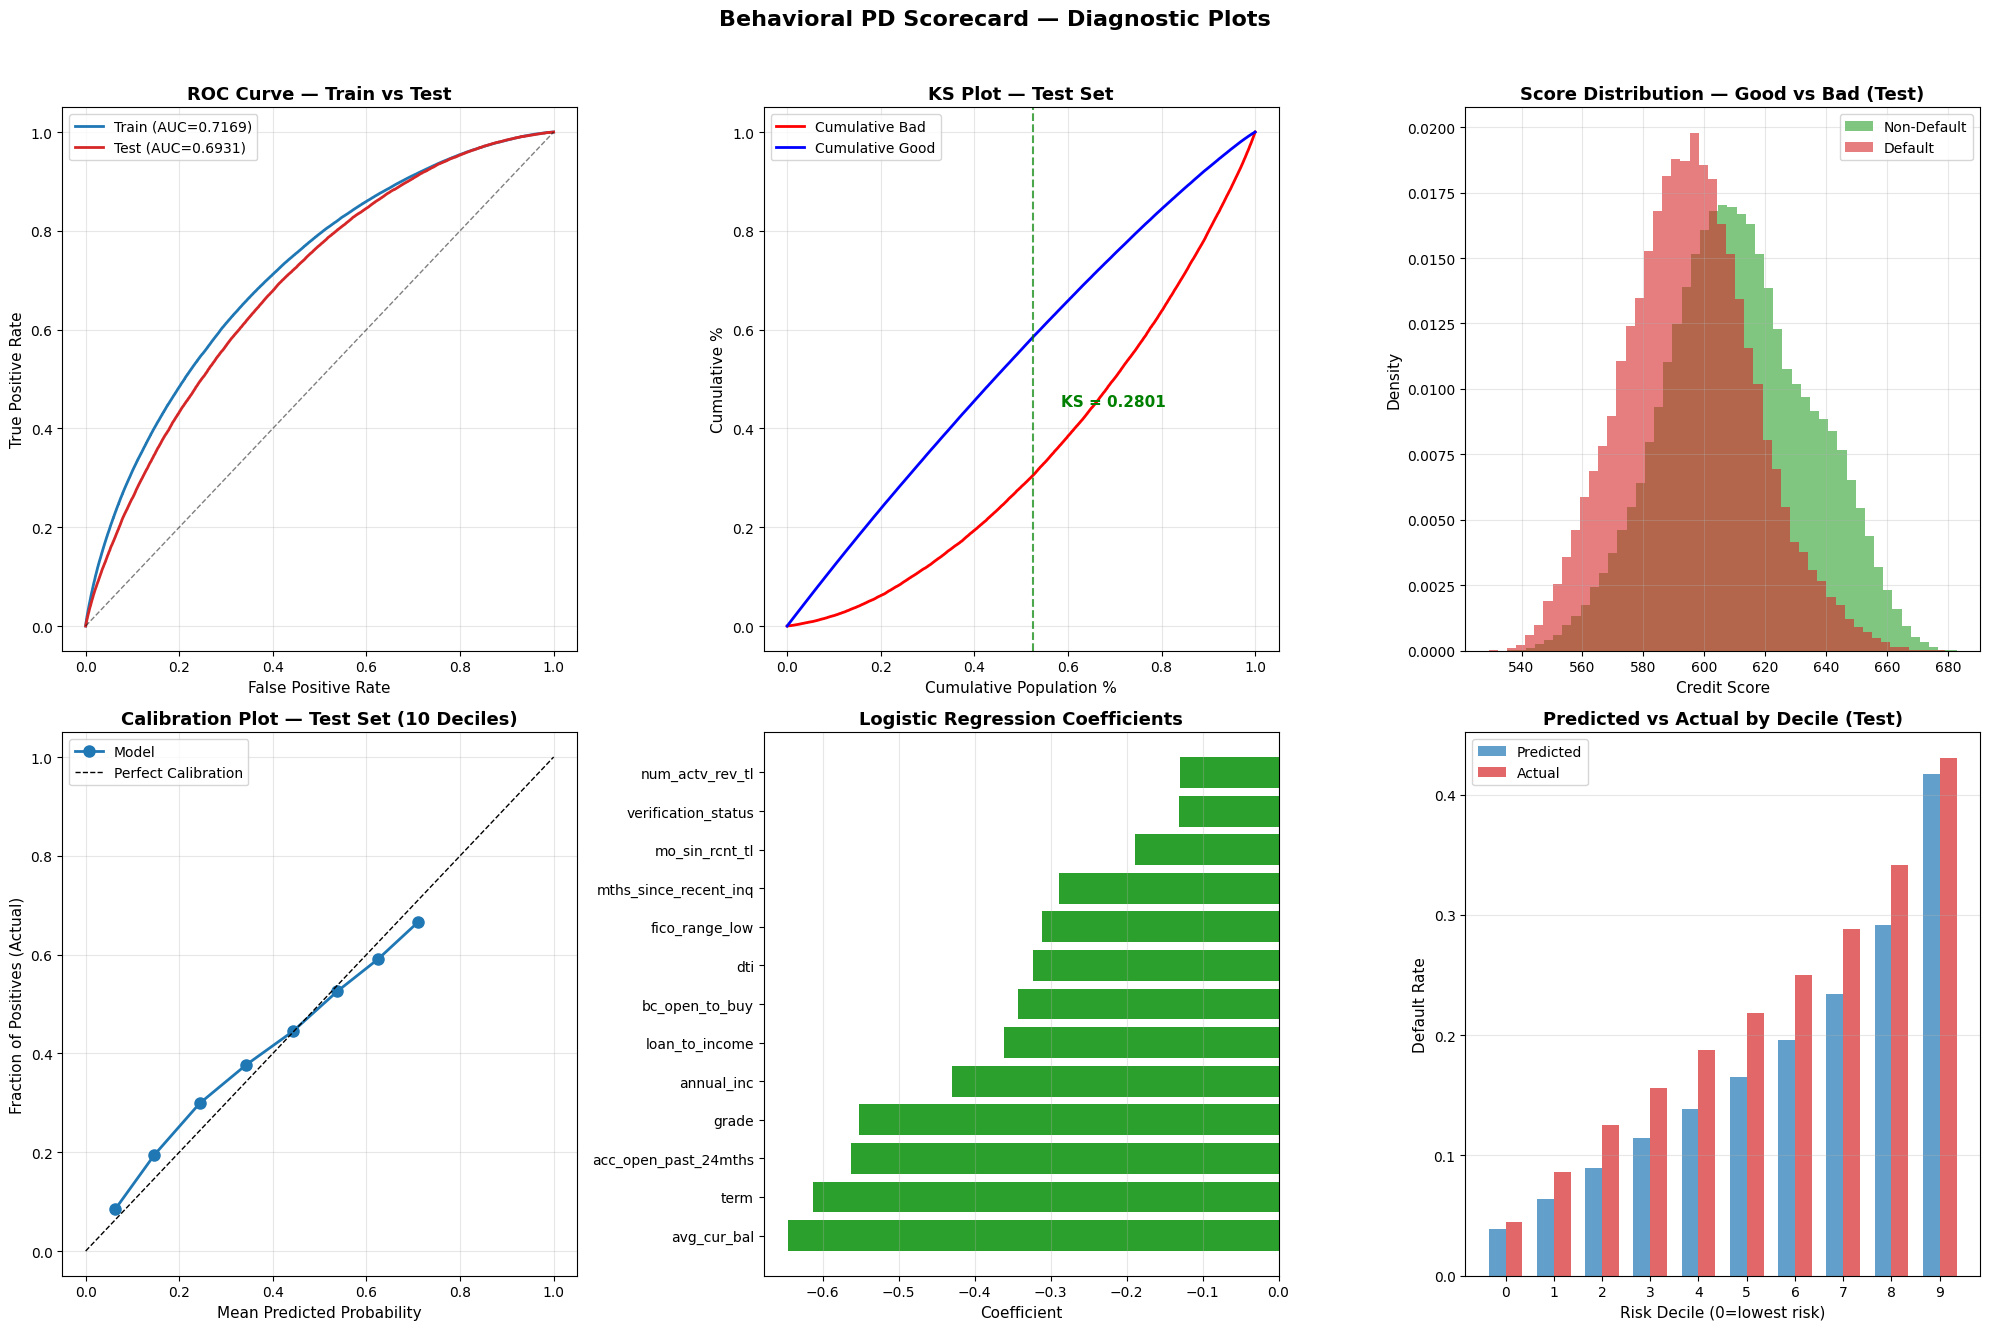

Saved: data/results/pd_scorecard_diagnostics.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# ── Plot 1: ROC Curve (train + test overlaid) ──
ax = axes[0, 0]
for name, y_true, y_proba, color in [
    ("Train", y_train, train_proba, "#1f77b4"),
    ("Test", y_test, test_proba, "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Train vs Test", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 2: KS Plot (test set) ──
ax = axes[0, 1]
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_proba)
ks_values = tpr_test - fpr_test
ks_idx = np.argmax(ks_values)
ks_threshold = thresholds_test[ks_idx] if ks_idx < len(thresholds_test) else 0.5

# Sort by predicted probability for KS plot
sorted_idx = np.argsort(test_proba)
cumulative_pct = np.arange(1, len(sorted_idx) + 1) / len(sorted_idx)
sorted_proba = test_proba[sorted_idx]
sorted_labels = y_test.values[sorted_idx]

cum_bad = np.cumsum(sorted_labels) / sorted_labels.sum()
cum_good = np.cumsum(1 - sorted_labels) / (1 - sorted_labels).sum()

ax.plot(cumulative_pct, cum_bad, "r-", linewidth=2, label="Cumulative Bad")
ax.plot(cumulative_pct, cum_good, "b-", linewidth=2, label="Cumulative Good")

ks_max_idx = np.argmax(np.abs(cum_bad - cum_good))
ax.axvline(x=cumulative_pct[ks_max_idx], color="green", linestyle="--", alpha=0.7)
ax.annotate(f"KS = {metrics_test['KS']:.4f}",
            xy=(cumulative_pct[ks_max_idx], (cum_bad[ks_max_idx] + cum_good[ks_max_idx]) / 2),
            fontsize=11, fontweight="bold", color="green",
            xytext=(20, 0), textcoords="offset points")

ax.set_xlabel("Cumulative Population %", fontsize=11)
ax.set_ylabel("Cumulative %", fontsize=11)
ax.set_title("KS Plot — Test Set", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 3: Score Distribution (good vs bad) ──
ax = axes[0, 2]
ax.hist(test_scores[y_test == 0], bins=50, alpha=0.6, label="Non-Default", color="#2ca02c", density=True)
ax.hist(test_scores[y_test == 1], bins=50, alpha=0.6, label="Default", color="#d62728", density=True)
ax.set_xlabel("Credit Score", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Score Distribution — Good vs Bad (Test)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 4: Calibration Plot ──
ax = axes[1, 0]
n_bins_cal = 10
fraction_positives, mean_predicted = calibration_curve(y_test, test_proba, n_bins=n_bins_cal)
ax.plot(mean_predicted, fraction_positives, "o-", color="#1f77b4", linewidth=2, markersize=8,
        label="Model")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect Calibration")
ax.set_xlabel("Mean Predicted Probability", fontsize=11)
ax.set_ylabel("Fraction of Positives (Actual)", fontsize=11)
ax.set_title("Calibration Plot — Test Set (10 Deciles)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 5: Coefficient Bar Chart ──
ax = axes[1, 1]
coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": lr_model.coef_.ravel(),
}).sort_values("coefficient")

colors = ["#d62728" if c > 0 else "#2ca02c" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient", fontsize=11)
ax.set_title("Logistic Regression Coefficients", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

# ── Plot 6: Predicted vs Actual by Decile ──
ax = axes[1, 2]
test_df_plot = pd.DataFrame({"actual": y_test.values, "predicted": test_proba})
test_df_plot["decile"] = pd.qcut(test_df_plot["predicted"], 10, labels=False, duplicates="drop")
decile_summary = test_df_plot.groupby("decile").agg(
    predicted_mean=("predicted", "mean"),
    actual_mean=("actual", "mean"),
    count=("actual", "count"),
).reset_index()

x_pos = np.arange(len(decile_summary))
width = 0.35
ax.bar(x_pos - width/2, decile_summary["predicted_mean"], width, label="Predicted", color="#1f77b4", alpha=0.7)
ax.bar(x_pos + width/2, decile_summary["actual_mean"], width, label="Actual", color="#d62728", alpha=0.7)
ax.set_xlabel("Risk Decile (0=lowest risk)", fontsize=11)
ax.set_ylabel("Default Rate", fontsize=11)
ax.set_title("Predicted vs Actual by Decile (Test)", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels([str(i) for i in range(len(decile_summary))])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Behavioral PD Scorecard — Diagnostic Plots", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "pd_scorecard_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/pd_scorecard_diagnostics.png")

## Step 11: Credit Policy Analysis

Evaluate the scorecard's practical utility at various score cutoffs.

**Risk-adjusted utility** accounts for the asymmetric cost of defaults vs the
benefit of performing loans. A default costs far more than a performing loan
generates in revenue. We use:

    utility = approval_rate × (1 - cost_ratio × default_rate)

where `cost_ratio = 4` reflects that the loss from one default roughly equals
the margin from ~4 performing loans (consistent with LGD ≈ 83% and annual
coupon margin ≈ 15-20% over 3-5 years).

The simple utility `approval_rate × (1 - default_rate)` is also shown for
reference but tends to maximize at 100% approval when discrimination is moderate.

In [14]:
# Build credit policy table
score_min = int(np.floor(test_scores.min() / 10) * 10)
score_max = int(np.ceil(test_scores.max() / 10) * 10)
cutoffs = list(range(score_min, score_max + 1, 10))

COST_RATIO = 4  # ~LGD/margin: 1 default ≈ cost of 4 performing loans

policy_rows = []
for cutoff in cutoffs:
    approved = test_scores >= cutoff
    n_approved = approved.sum()
    approval_rate = n_approved / len(test_scores)

    if n_approved > 0:
        default_rate = y_test.values[approved].mean()
        expected_loss = approval_rate * default_rate
    else:
        default_rate = 0.0
        expected_loss = 0.0

    simple_utility = approval_rate * (1 - default_rate)
    risk_adj_utility = approval_rate * (1 - COST_RATIO * default_rate)

    policy_rows.append({
        "cutoff": cutoff,
        "n_approved": n_approved,
        "approval_rate": approval_rate,
        "default_rate": default_rate,
        "expected_loss": expected_loss,
        "simple_utility": simple_utility,
        "risk_adj_utility": risk_adj_utility,
    })

policy_df = pd.DataFrame(policy_rows)

print("=" * 100)
print("CREDIT POLICY ANALYSIS — Score Cutoff Tradeoffs (Test Set)")
print("=" * 100)
print(f"{'Cutoff':>8s} {'N Approved':>12s} {'Approval%':>10s} {'Default%':>10s} "
      f"{'Exp Loss':>10s} {'Simple U':>10s} {'RiskAdj U':>10s}")
print("-" * 75)
for _, row in policy_df.iterrows():
    print(f"{int(row['cutoff']):>8d} {int(row['n_approved']):>12,d} "
          f"{row['approval_rate']:>10.2%} {row['default_rate']:>10.2%} "
          f"{row['expected_loss']:>10.4f} {row['simple_utility']:>10.4f} "
          f"{row['risk_adj_utility']:>10.4f}")

# Find optimal cutoff using risk-adjusted utility
# Only consider cutoffs where risk_adj_utility > 0 (i.e., portfolio is profitable)
profitable = policy_df[policy_df["risk_adj_utility"] > 0]
if len(profitable) > 0:
    optimal_idx = profitable["risk_adj_utility"].idxmax()
else:
    optimal_idx = policy_df["risk_adj_utility"].idxmax()

optimal_cutoff = policy_df.loc[optimal_idx, "cutoff"]
optimal_row = policy_df.loc[optimal_idx]

print(f"\nOptimal cutoff (risk-adjusted, cost_ratio={COST_RATIO}): {int(optimal_cutoff)}")
print(f"  Approval rate:      {optimal_row['approval_rate']:.2%}")
print(f"  Default rate:       {optimal_row['default_rate']:.2%}")
print(f"  Risk-adj utility:   {optimal_row['risk_adj_utility']:.4f}")
print(f"  Simple utility:     {optimal_row['simple_utility']:.4f}")

# Verify optimal is not the minimum score
if optimal_cutoff == policy_df["cutoff"].min():
    print("\n  WARNING: Optimal cutoff is the minimum score — scorecard may lack")
    print("  discrimination at practical thresholds. Review score distribution.")
else:
    print(f"\n  Optimal cutoff ({int(optimal_cutoff)}) is above minimum "
          f"({int(policy_df['cutoff'].min())}) — good discrimination.")

CREDIT POLICY ANALYSIS — Score Cutoff Tradeoffs (Test Set)
  Cutoff   N Approved  Approval%   Default%   Exp Loss   Simple U  RiskAdj U
---------------------------------------------------------------------------
     520      225,639    100.00%     21.29%     0.2129     0.7871     0.1483
     530      225,638    100.00%     21.29%     0.2129     0.7871     0.1483
     540      225,590     99.98%     21.28%     0.2128     0.7870     0.1487
     550      224,708     99.59%     21.15%     0.2106     0.7853     0.1534
     560      221,153     98.01%     20.68%     0.2027     0.7774     0.1694
     570      213,034     94.41%     19.82%     0.1871     0.7570     0.1956
     580      198,068     87.78%     18.43%     0.1618     0.7160     0.2307
     590      173,175     76.75%     16.38%     0.1257     0.6418     0.2647
     600      138,747     61.49%     13.88%     0.0853     0.5296     0.2736
     610      100,917     44.72%     11.10%     0.0496     0.3976     0.2487
     620       66,

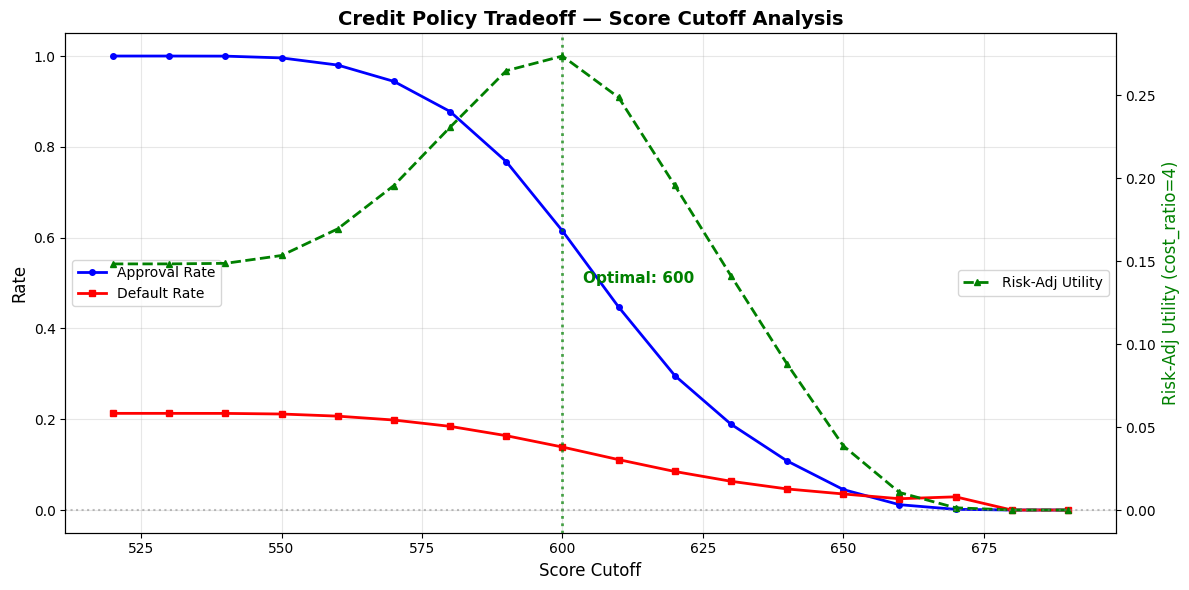

Saved: data/results/credit_policy_tradeoff.png


In [15]:
# ── Credit policy tradeoff plot ──
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(policy_df["cutoff"], policy_df["approval_rate"], "b-o",
         markersize=4, label="Approval Rate", linewidth=2)
ax1.plot(policy_df["cutoff"], policy_df["default_rate"], "r-s",
         markersize=4, label="Default Rate", linewidth=2)
ax1.set_xlabel("Score Cutoff", fontsize=12)
ax1.set_ylabel("Rate", fontsize=12)
ax1.legend(loc="center left", fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(policy_df["cutoff"], policy_df["risk_adj_utility"], "g--^",
         markersize=5, label="Risk-Adj Utility", linewidth=2)
ax2.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax2.set_ylabel(f"Risk-Adj Utility (cost_ratio={COST_RATIO})", fontsize=12, color="green")
ax2.legend(loc="center right", fontsize=10)

# Mark optimal
ax1.axvline(x=optimal_cutoff, color="green", linestyle=":", alpha=0.7, linewidth=2)
ax1.annotate(f"Optimal: {int(optimal_cutoff)}",
             xy=(optimal_cutoff, 0.5), fontsize=11, fontweight="bold", color="green",
             xytext=(15, 0), textcoords="offset points")

ax1.set_title("Credit Policy Tradeoff — Score Cutoff Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "credit_policy_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/credit_policy_tradeoff.png")

## Step 12: Model Score → LC Grade Mapping

Map the model's credit scores to LendingClub's letter grades (A–G) by
computing score percentile boundaries that correspond to the training
data's grade distribution.

In [16]:
# Compute grade distribution from training set
# We need the original grade labels — approximate from WoE values
# The binner has the bin table for grade with WoE → original grade mapping

grade_bins = binner.bin_tables_.get("grade", None)
if grade_bins is not None:
    print("Grade WoE Bin Table (from NB02 binner):")
    print(grade_bins[["bin", "count", "event_rate", "woe"]].to_string(index=False))
    print()

# Map scores to grades using percentile boundaries
# Use the training score distribution to define grade boundaries
# based on the original grade proportions in the data
train_sorted_scores = np.sort(train_scores)[::-1]  # Descending (high score = low risk)
n_total = len(train_sorted_scores)

# Approximate LC grade distribution from training data
# (these are roughly the proportions of A, B, C, D, E, F, G)
# Use actual proportions from the WoE bin table if available
if grade_bins is not None:
    grade_labels = []
    grade_counts = []
    for _, row in grade_bins.iterrows():
        bin_label = str(row["bin"])
        grade_labels.append(bin_label)
        grade_counts.append(int(row["count"]))

    # Build cumulative proportions
    total_count = sum(grade_counts)
    cumulative = np.cumsum(grade_counts) / total_count

    # Score boundaries at each cumulative proportion
    grade_boundaries = []
    for i, cum in enumerate(cumulative[:-1]):
        idx = int(cum * n_total)
        if idx < n_total:
            grade_boundaries.append(train_sorted_scores[idx])

    print("Score → Grade Mapping (based on training distribution):")
    print(f"{'Grade':<10s} {'Score Range':<25s} {'Population %':>12s} {'Default Rate':>12s}")
    print("-" * 62)

    # Create grade mapping for test set
    grade_map_rows = []
    for i, label in enumerate(grade_labels):
        if i == 0:
            lower = grade_boundaries[0] if grade_boundaries else train_sorted_scores[-1]
            mask = test_scores >= lower
            score_range = f"≥ {lower:.0f}"
        elif i == len(grade_labels) - 1:
            upper = grade_boundaries[i-1]
            mask = test_scores < upper
            score_range = f"< {upper:.0f}"
        else:
            upper = grade_boundaries[i-1]
            lower = grade_boundaries[i] if i < len(grade_boundaries) else train_sorted_scores[-1]
            mask = (test_scores >= lower) & (test_scores < upper)
            score_range = f"{lower:.0f} – {upper:.0f}"

        n = mask.sum()
        pct = n / len(test_scores)
        dr = y_test.values[mask].mean() if n > 0 else 0.0

        grade_map_rows.append({
            "grade": label,
            "score_range": score_range,
            "n_loans": n,
            "population_pct": pct,
            "default_rate": dr,
        })
        print(f"{label:<10s} {score_range:<25s} {pct:>11.2%} {dr:>12.2%}")

    grade_map_df = pd.DataFrame(grade_map_rows)
else:
    print("Grade bin table not available — skipping grade mapping.")
    grade_map_df = pd.DataFrame()

Grade WoE Bin Table (from NB02 binner):
    bin  count  event_rate     woe
    [A] 146430      0.0557  1.3429
    [B] 241511      0.1203  0.5014
    [C] 225234      0.2037 -0.1242
    [D] 126002      0.2813 -0.5497
 [E, F]  82564      0.3815 -1.0046
    [G]   4865      0.4674 -1.3573
Special      0      0.0000  0.0000
Missing      0      0.0000  0.0000
        826606      0.1843     NaN

Score → Grade Mapping (based on training distribution):
Grade      Score Range               Population % Default Rate
--------------------------------------------------------------
['A']      ≥ 641                          10.44%        4.60%
['B']      624 – 641                      14.22%        9.75%
['C']      614 – 624                      13.56%       14.45%
['D']      609 – 614                       7.68%       17.84%
['E' 'F']  606 – 609                       5.12%       19.51%
['G']      606 – 606                       0.30%       20.55%
Special    606 – 606                       0.00%       

## Step 13: Save All Outputs

| Output | Description |
|--------|-------------|
| `pd_logreg_model.pkl` | Fitted LogisticRegressionCV model |
| `scorecard_object.pkl` | Scorecard class instance (model + binner + params) |
| `scorecard_table.csv` | Publication-ready scorecard points table |
| `pd_scorecard_metrics.json` | Performance metrics (AUC, Gini, KS, Brier) |
| `credit_policy_analysis.csv` | Cutoff analysis with approval/default rates |

In [17]:
import json

# Ensure output directories exist
DATA_MODELS_PATH.mkdir(parents=True, exist_ok=True)
DATA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# ── Save model ──
model_path = DATA_MODELS_PATH / "pd_logreg_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(lr_model, f)
print(f"Saved: {model_path}")

# ── Save scorecard object ──
sc_path = DATA_MODELS_PATH / "scorecard_object.pkl"
with open(sc_path, "wb") as f:
    pickle.dump(sc, f)
print(f"Saved: {sc_path}")

# ── Save scorecard table ──
table_path = DATA_RESULTS_PATH / "scorecard_table.csv"
scorecard_table.to_csv(table_path, index=False)
print(f"Saved: {table_path}")

# ── Save metrics ──
metrics_dict = {
    "train": metrics_train,
    "validation": metrics_val,
    "test": metrics_test,
    "rag_status": rag_status,
    "test_gini_pct": round(test_gini * 100, 2),
    "train_test_auc_gap": round(auc_gap, 4),
    "optimal_cutoff": int(optimal_cutoff),
    "n_features": len(final_features),
    "features": final_features,
    "best_C": float(lr_model.C_[0]),
    "base_score": SCORECARD_BASE,
    "pdo": SCORECARD_PDO,
    "base_odds": float(base_odds),
}
metrics_path = DATA_RESULTS_PATH / "pd_scorecard_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)
print(f"Saved: {metrics_path}")

# ── Save credit policy analysis ──
policy_path = DATA_RESULTS_PATH / "credit_policy_analysis.csv"
policy_df.to_csv(policy_path, index=False)
print(f"Saved: {policy_path}")

# ── Final summary ──
print(f"\n{'=' * 80}")
print("NOTEBOOK 03 SUMMARY — Behavioral PD Scorecard")
print(f"{'=' * 80}")
print(f"  Model:           L2 Logistic Regression (C={lr_model.C_[0]:.4f})")
print(f"  Features:        {len(final_features)}")
print(f"  Test AUC:        {metrics_test['AUC']:.4f}")
print(f"  Test Gini:       {metrics_test['Gini']:.4f} ({metrics_test['Gini']*100:.1f}%)")
print(f"  Test KS:         {metrics_test['KS']:.4f}")
print(f"  RAG Status:      {rag_status}")
print(f"  Optimal Cutoff:  {int(optimal_cutoff)}")
print(f"  Train-Test Gap:  {auc_gap:.4f}")
print()
print("Files saved:")
print(f"  data/models/pd_logreg_model.pkl")
print(f"  data/models/scorecard_object.pkl")
print(f"  data/results/scorecard_table.csv")
print(f"  data/results/pd_scorecard_metrics.json")
print(f"  data/results/credit_policy_analysis.csv")
print(f"  data/results/pd_scorecard_diagnostics.png")
print(f"  data/results/credit_policy_tradeoff.png")
print()
print("→ Next: Notebook 04 — ML PD Models (XGBoost, LightGBM)")
print("  Will include grade + int_rate + sub_grade + macro features")
print("  to establish performance ceiling with non-linear models.")

Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/models/pd_logreg_model.pkl
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/models/scorecard_object.pkl
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/results/scorecard_table.csv
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/results/pd_scorecard_metrics.json
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/results/credit_policy_analysis.csv

NOTEBOOK 03 SUMMARY — Behavioral PD Scorecard
  Model:           L2 Logistic Regression (C=0.1000)
  Features:        13
  Test AUC:        0.6931
  Test Gini:       0.3862 (38.6%)
  Test KS:         0.2801
  RAG Status:      RED
  Optimal Cutoff:  600
  Train-Test Gap:  0.0238

Files saved: